# PyTorch CNN을 활용한 Fashion-MNIST 패션 아이템 분류

코드의 핵심 흐름은 다음과 같습니다.

1. Fashion-MNIST 데이터셋 불러오기
2. 이미지 픽셀값을 `[0, 1]` 범위로 정규화하기
3. CNN 입력 형태에 맞게 채널 차원 추가하기
4. 합성곱층, 풀링층, 완전연결층으로 CNN 모델 만들기
5. Adam 최적화 알고리즘과 Cross Entropy 손실 함수로 학습하기
6. 테스트 데이터로 정확도, 혼동 행렬, F1 점수 확인하기

PyTorch에서는 Keras와 달리 이미지 텐서의 차원 순서가 다릅니다.

- Keras: `(데이터개수, 높이, 너비, 채널)` → 예: `(60000, 28, 28, 1)`
- PyTorch: `(데이터개수, 채널, 높이, 너비)` → 예: `(60000, 1, 28, 28)`

따라서 PyTorch CNN에서는 `1 x 28 x 28` 형태의 이미지를 입력으로 사용합니다.


In [2]:
# ===============================
# 1. 필요한 라이브러리 임포트
# ===============================

# 숫자 계산을 위한 라이브러리입니다.
# 배열 처리, 난수 생성, 수치 연산 등에 사용합니다.
import numpy as np

# 그래프와 이미지를 화면에 출력하기 위한 라이브러리입니다.
# 학습 데이터 샘플 이미지 확인과 결과 시각화에 사용합니다.
import matplotlib.pyplot as plt

# 코드 실행 시간을 측정하기 위해 사용하는 함수입니다.
# 학습 시작 시간과 종료 시간을 비교하여 총 학습 시간을 계산합니다.
from time import time

# PyTorch의 핵심 라이브러리입니다.
# 텐서 생성, GPU 연산, 자동 미분 등에 사용합니다.
import torch

# PyTorch에서 신경망 층을 만들기 위한 모듈입니다.
# Conv2d, MaxPool2d, Linear, ReLU 같은 층을 제공합니다.
import torch.nn as nn

# PyTorch에서 최적화 알고리즘을 제공하는 모듈입니다.
# Adam, SGD 같은 optimizer를 사용할 수 있습니다.
import torch.optim as optim

# PyTorch에서 데이터셋과 미니배치 처리를 도와주는 클래스입니다.
# TensorDataset은 텐서 데이터를 데이터셋 형태로 묶어줍니다.
# DataLoader는 데이터를 batch 단위로 나누어 모델에 공급합니다.
from torch.utils.data import TensorDataset, DataLoader

# torchvision은 이미지 데이터셋과 이미지 전처리 기능을 제공하는 PyTorch 보조 라이브러리입니다.
# FashionMNIST 데이터셋을 불러올 때 사용합니다.
from torchvision import datasets

# 이미지 데이터를 텐서로 바꾸고 정규화하는 전처리 기능을 제공합니다.
from torchvision import transforms

# 모델 성능 평가를 위해 혼동 행렬을 계산하는 함수입니다.
from sklearn.metrics import confusion_matrix

# 모델 성능 평가를 위해 F1 점수를 계산하는 함수입니다.
from sklearn.metrics import f1_score

# 코드 실행 결과가 매번 지나치게 달라지지 않도록 난수 시드를 고정합니다.
# 딥러닝은 가중치 초기화와 데이터 섞기 과정에 난수가 사용됩니다.
torch.manual_seed(42)

# NumPy에서 사용하는 난수 시드도 고정합니다.
np.random.seed(42)

# GPU가 사용 가능한 환경이면 GPU를 사용하고, 그렇지 않으면 CPU를 사용합니다.
# 구글 코랩에서 런타임 유형을 GPU로 설정하면 cuda가 선택됩니다.
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 현재 선택된 연산 장치를 출력합니다.
# cuda가 출력되면 GPU를 사용한다는 의미이고, cpu가 출력되면 CPU를 사용한다는 의미입니다.
print("사용 장치:", device)


사용 장치: cpu


In [4]:
# ===============================
# 2. 하이퍼파라미터 설정
# ===============================

# 학습 반복 횟수입니다.
# 처음 실습할 때 시간이 오래 걸리면 3 정도로 줄여도 됩니다.
M_EPOCH = 20

# 한 번의 학습 단계에서 사용할 데이터 개수입니다.
M_BATCH = 300

# Fashion-MNIST는 총 10개의 패션 아이템 클래스를 가집니다.
# 예: 티셔츠, 바지, 풀오버, 드레스, 코트, 샌들, 셔츠, 운동화, 가방, 앵클부츠
M_CLASS = 10

# 학습률은 optimizer가 가중치를 얼마나 크게 수정할지 결정하는 값입니다.
# Adam에서는 보통 0.001을 기본값으로 많이 사용합니다.
M_LR = 0.001

# Fashion-MNIST 클래스 번호를 사람이 이해하기 쉬운 이름으로 바꿔주는 리스트입니다.
# 모델은 숫자 라벨을 사용하지만, 결과 해석에서는 문자 이름이 더 직관적입니다.
class_names = [
    "T-shirt/top",  # 0번 클래스: 티셔츠 또는 상의
    "Trouser",      # 1번 클래스: 바지
    "Pullover",     # 2번 클래스: 풀오버
    "Dress",        # 3번 클래스: 드레스
    "Coat",         # 4번 클래스: 코트
    "Sandal",       # 5번 클래스: 샌들
    "Shirt",        # 6번 클래스: 셔츠
    "Sneaker",      # 7번 클래스: 운동화
    "Bag",          # 8번 클래스: 가방
    "Ankle boot"    # 9번 클래스: 앵클부츠
]


## 3. 데이터 준비

PyTorch에서는 `torchvision.datasets.FashionMNIST`를 사용합니다.

`transforms.ToTensor()`는 다음 두 가지 처리를 자동으로 수행합니다.

1. 이미지 데이터를 PyTorch 텐서로 변환합니다.
2. 픽셀값을 `0~255` 범위에서 `0~1` 범위로 변환합니다.



In [5]:
# ===============================
# 3. Fashion-MNIST 데이터셋 불러오기
# ===============================

# transforms.Compose는 여러 전처리 작업을 순서대로 묶는 도구입니다.
# 여기서는 ToTensor 하나만 사용하지만, 나중에 Normalize 등을 추가할 수 있습니다.
transform = transforms.Compose([
    # PIL 이미지 또는 NumPy 이미지를 PyTorch Tensor로 변환합니다.
    # Fashion-MNIST의 흑백 이미지는 변환 후 모양이 (1, 28, 28)이 됩니다.
    # 또한 픽셀값을 0~255에서 0~1 범위의 실수값으로 자동 변환합니다.
    transforms.ToTensor()
])

# 학습용 Fashion-MNIST 데이터셋을 다운로드하고 불러옵니다.
# root='./data'는 데이터가 저장될 폴더 위치입니다.
# train=True는 학습용 데이터 60,000장을 사용한다는 의미입니다.
# download=True는 데이터가 없으면 자동으로 다운로드한다는 의미입니다.
# transform=transform은 위에서 정의한 전처리를 이미지에 적용한다는 의미입니다.
train_dataset = datasets.FashionMNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

# 평가용 Fashion-MNIST 데이터셋을 다운로드하고 불러옵니다.
# train=False는 테스트 데이터 10,000장을 사용한다는 의미입니다.
test_dataset = datasets.FashionMNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

# 학습용 데이터셋의 전체 개수를 출력합니다.
print("학습용 데이터 개수:", len(train_dataset))

# 평가용 데이터셋의 전체 개수를 출력합니다.
print("평가용 데이터 개수:", len(test_dataset))

# 학습용 데이터 하나를 꺼내어 이미지와 라벨을 확인합니다.
# sample_image는 이미지 텐서이고, sample_label은 정답 클래스 번호입니다.
sample_image, sample_label = train_dataset[0]

# PyTorch 이미지 텐서의 모양을 출력합니다.
# Fashion-MNIST 한 장은 채널 1개, 높이 28, 너비 28이므로 (1, 28, 28)입니다.
print("샘플 이미지 텐서 모양:", sample_image.shape)

# 샘플 이미지의 라벨 번호를 출력합니다.
print("샘플 데이터 라벨 번호:", sample_label)

# 샘플 이미지의 라벨 이름을 출력합니다.
print("샘플 데이터 라벨 이름:", class_names[sample_label])


100%|██████████| 26.4M/26.4M [00:01<00:00, 14.5MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 216kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.97MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 11.9MB/s]

학습용 데이터 개수: 60000
평가용 데이터 개수: 10000
샘플 이미지 텐서 모양: torch.Size([1, 28, 28])
샘플 데이터 라벨 번호: 9
샘플 데이터 라벨 이름: Ankle boot


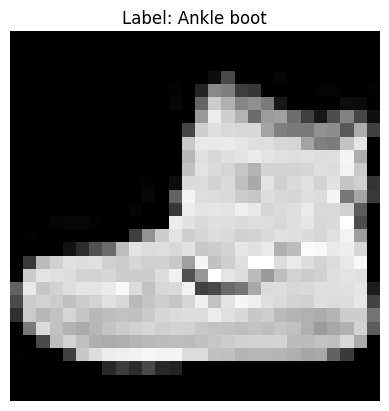

tensor([[[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0039, 0.0000, 0.0000, 0.0510,
          0.2863, 0.0000, 0.0000, 0.0039, 0.0157, 0.0000,

In [6]:
# ===============================
# 4. 샘플 이미지 시각화
# ===============================

# sample_image는 (1, 28, 28) 형태입니다.
# matplotlib의 imshow는 보통 (28, 28) 형태의 2차원 이미지를 기대합니다.
# squeeze()는 크기가 1인 채널 차원을 제거하여 (28, 28) 형태로 만듭니다.
plt.imshow(sample_image.squeeze(), cmap="gray")

# 그래프 제목에 실제 라벨 이름을 표시합니다.
plt.title(f"Label: {class_names[sample_label]}")

# 이미지 축의 숫자 눈금을 숨깁니다.
plt.axis("off")

# 그래프를 화면에 출력합니다.
plt.show()

# 이미지 텐서의 실제 숫자값 일부를 출력합니다.
# 값이 0~1 사이로 변환되어 있는지 확인할 수 있습니다.
print(sample_image)


In [7]:
# ===============================
# 5. DataLoader 생성
# ===============================

# DataLoader는 전체 데이터를 batch 단위로 나누어 모델에 전달합니다.
# shuffle=True는 매 epoch마다 학습 데이터 순서를 섞는다는 의미입니다.
# 데이터 순서를 섞으면 모델이 특정 순서에만 익숙해지는 것을 줄일 수 있습니다.
train_loader = DataLoader(
    dataset=train_dataset,
    batch_size=M_BATCH,
    shuffle=True
)

# 테스트 데이터는 평가용이므로 순서를 섞을 필요가 없습니다.
# shuffle=False로 두면 항상 같은 순서로 평가합니다.
test_loader = DataLoader(
    dataset=test_dataset,
    batch_size=M_BATCH,
    shuffle=False
)

# DataLoader에서 첫 번째 미니배치를 하나 꺼내어 모양을 확인합니다.
batch_images, batch_labels = next(iter(train_loader))

# 미니배치 이미지의 모양을 출력합니다.
# 모양은 (batch_size, channel, height, width)입니다.
print("미니배치 입력 데이터 모양:", batch_images.shape)

# 미니배치 라벨의 모양을 출력합니다.
# 라벨은 one-hot이 아니라 정수 클래스 번호 형태입니다.
print("미니배치 정답 라벨 모양:", batch_labels.shape)

# 첫 번째 미니배치의 앞 10개 라벨을 확인합니다.
print("미니배치 라벨 샘플:", batch_labels[:10])


미니배치 입력 데이터 모양: torch.Size([300, 1, 28, 28])
미니배치 정답 라벨 모양: torch.Size([300])
미니배치 라벨 샘플: tensor([5, 7, 4, 7, 3, 8, 9, 5, 3, 1])


## 6. CNN 모델 구현

모델 구조는 다음과 같습니다.

```text
InputLayer(28, 28, 1)
Conv2D(32, kernel_size=2, padding='same', activation='relu')
MaxPool2D(pool_size=2)
Conv2D(64, kernel_size=2, padding='same', activation='relu')
MaxPool2D(pool_size=2)
Flatten()
Dense(128, activation='relu')
Dense(10, activation='softmax')
```

PyTorch에서는 마지막에 `Softmax`를 직접 넣지 않습니다.  
그 이유는 `nn.CrossEntropyLoss()`가 내부적으로 `LogSoftmax + Negative Log Likelihood Loss`를 함께 처리하기 때문입니다.

따라서 PyTorch 모델의 마지막 출력은 확률값이 아니라 각 클래스에 대한 점수인 `logits`입니다.


In [8]:
# ===============================
# 6. CNN 모델 클래스 정의
# ===============================

# nn.Module은 PyTorch에서 모든 신경망 모델의 기본 부모 클래스입니다.
# 사용자가 직접 모델을 만들 때는 nn.Module을 상속받아 클래스를 작성합니다.
class FashionCNN(nn.Module):

    # __init__은 모델에 들어갈 층을 정의하는 부분입니다.
    # 모델 객체가 생성될 때 한 번 실행됩니다.
    def __init__(self):

        # 부모 클래스인 nn.Module의 초기화 기능을 먼저 실행합니다.
        super(FashionCNN, self).__init__()

        # 첫 번째 합성곱층입니다.
        # in_channels=1은 흑백 이미지라서 입력 채널이 1개라는 뜻입니다.
        # out_channels=32는 32개의 필터를 사용하여 32개의 특징맵을 만든다는 뜻입니다.
        # kernel_size=2는 2x2 크기의 필터를 사용한다는 뜻입니다.
        # padding='same'은 입력 이미지의 가로세로 크기가 합성곱 후에도 유지되도록 패딩을 추가합니다.
        self.conv1 = nn.Conv2d(
            in_channels=1,
            out_channels=32,
            kernel_size=2,
            padding="same"
        )

        # 첫 번째 풀링층입니다.
        # kernel_size=2는 2x2 영역에서 가장 큰 값을 하나 선택한다는 뜻입니다.
        # MaxPool2d는 이미지 크기를 줄이면서 중요한 특징을 남기는 역할을 합니다.
        self.pool1 = nn.MaxPool2d(kernel_size=2)

        # 두 번째 합성곱층입니다.
        # 첫 번째 합성곱층의 출력 채널이 32개이므로 in_channels=32입니다.
        # out_channels=64는 64개의 특징맵을 만든다는 뜻입니다.
        self.conv2 = nn.Conv2d(
            in_channels=32,
            out_channels=64,
            kernel_size=2,
            padding="same"
        )

        # 두 번째 풀링층입니다.
        # 다시 2x2 영역에서 최댓값을 뽑아 이미지 크기를 절반으로 줄입니다.
        self.pool2 = nn.MaxPool2d(kernel_size=2)

        # ReLU 활성화 함수입니다.
        # 음수는 0으로 만들고 양수는 그대로 통과시켜 비선형성을 추가합니다.
        self.relu = nn.ReLU()

        # 첫 번째 완전연결층입니다.
        # 입력 크기 64 * 7 * 7의 의미는 다음과 같습니다.
        # 원본 이미지 28x28 → 첫 번째 풀링 후 14x14 → 두 번째 풀링 후 7x7
        # 두 번째 합성곱층의 출력 채널이 64개이므로 최종 특징 수는 64*7*7입니다.
        # 출력 크기 128은 128개의 은닉 노드를 사용한다는 뜻입니다.
        self.fc1 = nn.Linear(64 * 7 * 7, 128)

        # 출력층입니다.
        # Fashion-MNIST는 10개 클래스를 분류하므로 출력 노드 수를 10개로 설정합니다.
        # 이 층의 출력은 softmax 확률이 아니라 CrossEntropyLoss에 들어갈 logits입니다.
        self.fc2 = nn.Linear(128, M_CLASS)

    # forward는 입력 데이터가 모델 안에서 어떤 순서로 계산되는지 정의하는 부분입니다.
    # 모델을 호출할 때마다 실행됩니다.
    def forward(self, x):

        # 입력 x의 모양은 (batch_size, 1, 28, 28)입니다.
        # 첫 번째 합성곱층을 통과하여 32개의 특징맵을 만듭니다.
        x = self.conv1(x)

        # 첫 번째 합성곱 결과에 ReLU 활성화 함수를 적용합니다.
        x = self.relu(x)

        # 첫 번째 풀링을 적용하여 이미지 크기를 28x28에서 14x14로 줄입니다.
        x = self.pool1(x)

        # 두 번째 합성곱층을 통과하여 64개의 특징맵을 만듭니다.
        x = self.conv2(x)

        # 두 번째 합성곱 결과에 ReLU 활성화 함수를 적용합니다.
        x = self.relu(x)

        # 두 번째 풀링을 적용하여 이미지 크기를 14x14에서 7x7로 줄입니다.
        x = self.pool2(x)

        # 합성곱층의 출력은 4차원 텐서입니다.
        # 완전연결층에 넣기 위해 2차원 텐서로 펼칩니다.
        # x.size(0)은 현재 batch_size를 의미합니다.
        x = x.view(x.size(0), -1)

        # 첫 번째 완전연결층을 통과하여 128개의 특징으로 변환합니다.
        x = self.fc1(x)

        # 완전연결층 결과에 ReLU 활성화 함수를 적용합니다.
        x = self.relu(x)

        # 출력층을 통과하여 10개 클래스에 대한 점수를 만듭니다.
        x = self.fc2(x)

        # 최종 출력값을 반환합니다.
        return x


In [9]:
# ===============================
# 7. 모델 생성 및 구조 확인
# ===============================

# FashionCNN 클래스를 이용하여 CNN 모델 객체를 생성합니다.
model = FashionCNN()

# 모델을 CPU 또는 GPU 장치로 이동합니다.
# 입력 데이터와 모델은 반드시 같은 장치에 있어야 연산할 수 있습니다.
model = model.to(device)

# 모델 구조를 출력합니다.
# 층 구성을 확인하는 용도입니다.
print(model)

# 테스트용 더미 입력 데이터를 하나 만들어 모델 출력 모양을 확인합니다.
# 1장의 흑백 이미지이므로 모양은 (1, 1, 28, 28)입니다.
dummy_input = torch.randn(1, 1, 28, 28).to(device)

# 모델에 더미 입력을 넣어 출력을 계산합니다.
dummy_output = model(dummy_input)

# 출력 모양을 확인합니다.
# 10개 클래스를 분류하므로 결과 모양은 (1, 10)이 됩니다.
print("더미 출력 모양:", dummy_output.shape)


FashionCNN(
  (conv1): Conv2d(1, 32, kernel_size=(2, 2), stride=(1, 1), padding=same)
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(32, 64, kernel_size=(2, 2), stride=(1, 1), padding=same)
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (relu): ReLU()
  (fc1): Linear(in_features=3136, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)
더미 출력 모양: torch.Size([1, 10])


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/conv.py:548: UserWarning: Using padding='same' with even kernel lengths and odd dilation may require a zero-padded copy of the input be created (Triggered internally at /pytorch/aten/src/ATen/native/Convolution.cpp:1024.)
  return F.conv2d(


## 8. 손실 함수와 최적화 알고리즘 설정

PyTorch에서는 다음처럼 나누어 작성합니다.

- 손실 함수: `nn.CrossEntropyLoss()`
- 최적화 알고리즘: `optim.Adam()`

주의할 점은 PyTorch의 `CrossEntropyLoss`는 정답 라벨을 one-hot encoding 형태로 받지 않고, `0~9` 사이의 정수 라벨로 받습니다.


In [10]:
# ===============================
# 8. 손실 함수와 optimizer 정의
# ===============================

# 다중 분류 문제에서 사용하는 손실 함수입니다.
# 모델 출력값은 softmax를 통과하지 않은 logits이어야 합니다.
# 정답 라벨은 one-hot이 아니라 0~9 사이의 정수 클래스 번호여야 합니다.
criterion = nn.CrossEntropyLoss()

# Adam 최적화 알고리즘을 생성합니다.
# model.parameters()는 모델 내부의 학습 가능한 가중치와 편향을 의미합니다.
# lr=M_LR은 학습률을 0.001로 설정한다는 뜻입니다.
optimizer = optim.Adam(model.parameters(), lr=M_LR)


In [11]:
# ===============================
# 9. 학습 함수 정의
# ===============================

# 한 epoch 동안 모델을 학습시키는 함수입니다.
def train_one_epoch(model, train_loader, criterion, optimizer, device):

    # 모델을 학습 모드로 전환합니다.
    # Dropout이나 BatchNorm 같은 층은 학습 모드와 평가 모드에서 동작이 다릅니다.
    # 현재 모델에는 Dropout이 없지만, 일반적으로 학습 전에 train()을 호출합니다.
    model.train()

    # 한 epoch 동안 누적할 손실값입니다.
    running_loss = 0.0

    # 맞게 예측한 데이터 개수를 누적할 변수입니다.
    correct = 0

    # 전체 데이터 개수를 누적할 변수입니다.
    total = 0

    # DataLoader에서 미니배치 단위로 이미지와 라벨을 꺼냅니다.
    for images, labels in train_loader:

        # 이미지 데이터를 현재 연산 장치로 이동합니다.
        images = images.to(device)

        # 정답 라벨 데이터를 현재 연산 장치로 이동합니다.
        labels = labels.to(device)

        # 이전 미니배치에서 계산된 기울기를 0으로 초기화합니다.
        # PyTorch는 기본적으로 gradient를 누적하므로 매 반복마다 초기화가 필요합니다.
        optimizer.zero_grad()

        # 모델에 이미지를 입력하여 10개 클래스에 대한 예측 점수를 계산합니다.
        outputs = model(images)

        # 예측 점수와 실제 정답 라벨을 비교하여 손실값을 계산합니다.
        loss = criterion(outputs, labels)

        # 손실값을 기준으로 역전파를 수행하여 각 가중치의 기울기를 계산합니다.
        loss.backward()

        # 계산된 기울기를 이용하여 모델의 가중치와 편향을 업데이트합니다.
        optimizer.step()

        # 현재 미니배치 손실값에 데이터 개수를 곱해 누적합니다.
        # 이렇게 하면 마지막에 전체 평균 손실을 정확히 계산할 수 있습니다.
        running_loss += loss.item() * images.size(0)

        # outputs에서 가장 큰 점수를 가진 클래스 번호를 예측값으로 선택합니다.
        _, predicted = torch.max(outputs, dim=1)

        # 현재 미니배치의 데이터 개수를 전체 개수에 더합니다.
        total += labels.size(0)

        # 예측값과 정답값이 같은 개수를 세어 correct에 더합니다.
        correct += (predicted == labels).sum().item()

    # 전체 학습 데이터에 대한 평균 손실을 계산합니다.
    epoch_loss = running_loss / total

    # 전체 학습 데이터에 대한 정확도를 계산합니다.
    epoch_acc = correct / total

    # 평균 손실과 정확도를 반환합니다.
    return epoch_loss, epoch_acc


In [12]:
# ===============================
# 10. 평가 함수 정의
# ===============================

# 테스트 데이터로 모델을 평가하는 함수입니다.
def evaluate(model, test_loader, criterion, device):

    # 모델을 평가 모드로 전환합니다.
    # 평가 시에는 가중치를 업데이트하지 않으며, Dropout 등이 비활성화됩니다.
    model.eval()

    # 평가 데이터 전체의 손실을 누적할 변수입니다.
    running_loss = 0.0

    # 맞게 예측한 데이터 개수를 누적할 변수입니다.
    correct = 0

    # 전체 평가 데이터 개수를 누적할 변수입니다.
    total = 0

    # 혼동 행렬과 F1 점수 계산을 위해 전체 예측값을 저장할 리스트입니다.
    all_preds = []

    # 혼동 행렬과 F1 점수 계산을 위해 전체 정답값을 저장할 리스트입니다.
    all_labels = []

    # torch.no_grad()는 평가 과정에서 기울기 계산을 하지 않도록 합니다.
    # 평가할 때는 역전파가 필요 없으므로 메모리 사용량과 계산 시간이 줄어듭니다.
    with torch.no_grad():

        # 테스트 DataLoader에서 미니배치 단위로 이미지와 라벨을 꺼냅니다.
        for images, labels in test_loader:

            # 이미지 데이터를 현재 연산 장치로 이동합니다.
            images = images.to(device)

            # 정답 라벨 데이터를 현재 연산 장치로 이동합니다.
            labels = labels.to(device)

            # 모델에 이미지를 입력하여 예측 점수를 계산합니다.
            outputs = model(images)

            # 예측 점수와 실제 정답 라벨을 비교하여 손실값을 계산합니다.
            loss = criterion(outputs, labels)

            # 현재 미니배치 손실값에 데이터 개수를 곱해 누적합니다.
            running_loss += loss.item() * images.size(0)

            # 가장 큰 점수를 가진 클래스 번호를 예측값으로 선택합니다.
            _, predicted = torch.max(outputs, dim=1)

            # 현재 미니배치의 데이터 개수를 전체 개수에 더합니다.
            total += labels.size(0)

            # 예측값과 정답값이 같은 개수를 세어 correct에 더합니다.
            correct += (predicted == labels).sum().item()

            # 예측값 텐서를 CPU로 이동한 뒤 NumPy 배열로 변환하고 리스트에 추가합니다.
            all_preds.extend(predicted.cpu().numpy())

            # 정답 라벨 텐서를 CPU로 이동한 뒤 NumPy 배열로 변환하고 리스트에 추가합니다.
            all_labels.extend(labels.cpu().numpy())

    # 전체 평가 데이터에 대한 평균 손실을 계산합니다.
    test_loss = running_loss / total

    # 전체 평가 데이터에 대한 정확도를 계산합니다.
    test_acc = correct / total

    # 손실, 정확도, 전체 정답값, 전체 예측값을 반환합니다.
    return test_loss, test_acc, np.array(all_labels), np.array(all_preds)


In [15]:
# ===============================
# 11. CNN 모델 학습
# ===============================

# 학습 시작 시간을 저장합니다.
begin = time()

# 학습 시작 메시지를 출력합니다.
print("CNN 학습 시작")

# epoch별 학습 손실과 정확도를 저장할 리스트입니다.
train_losses = []
train_accuracies = []

# 지정한 epoch 수만큼 반복 학습합니다.
# range(1, M_EPOCH + 1)을 사용하면 epoch 번호가 1부터 시작됩니다.
for epoch in range(1, M_EPOCH + 1):

    # 한 epoch 동안 학습을 수행하고 평균 손실과 정확도를 받습니다.
    train_loss, train_acc = train_one_epoch(
        model=model,
        train_loader=train_loader,
        criterion=criterion,
        optimizer=optimizer,
        device=device
    )

    # 현재 epoch의 학습 손실을 리스트에 저장합니다.
    train_losses.append(train_loss)

    # 현재 epoch의 학습 정확도를 리스트에 저장합니다.
    train_accuracies.append(train_acc)

    # 현재 epoch의 학습 결과를 출력합니다.
    print(
        f"Epoch [{epoch:02d}/{M_EPOCH}] "
        f"Loss: {train_loss:.4f} "
        f"Accuracy: {train_acc * 100:.2f}%"
    )

# 학습 종료 시간을 저장합니다.
end = time()

# 총 학습 시간을 출력합니다.
print("총 학습 시간: {:.1f}초".format(end - begin))


CNN 학습 시작
Epoch [01/20] Loss: 0.6698 Accuracy: 76.61%
Epoch [02/20] Loss: 0.3893 Accuracy: 85.84%
Epoch [03/20] Loss: 0.3318 Accuracy: 88.07%
Epoch [04/20] Loss: 0.3046 Accuracy: 89.07%
Epoch [05/20] Loss: 0.2874 Accuracy: 89.71%
Epoch [06/20] Loss: 0.2692 Accuracy: 90.14%
Epoch [07/20] Loss: 0.2535 Accuracy: 90.75%
Epoch [08/20] Loss: 0.2429 Accuracy: 91.17%
Epoch [09/20] Loss: 0.2306 Accuracy: 91.62%
Epoch [10/20] Loss: 0.2232 Accuracy: 91.80%
Epoch [11/20] Loss: 0.2121 Accuracy: 92.19%
Epoch [12/20] Loss: 0.2030 Accuracy: 92.52%
Epoch [13/20] Loss: 0.1968 Accuracy: 92.72%
Epoch [14/20] Loss: 0.1905 Accuracy: 93.04%
Epoch [15/20] Loss: 0.1802 Accuracy: 93.44%
Epoch [16/20] Loss: 0.1740 Accuracy: 93.64%
Epoch [17/20] Loss: 0.1660 Accuracy: 93.96%
Epoch [18/20] Loss: 0.1621 Accuracy: 94.04%
Epoch [19/20] Loss: 0.1595 Accuracy: 94.00%
Epoch [20/20] Loss: 0.1442 Accuracy: 94.79%
총 학습 시간: 1391.6초


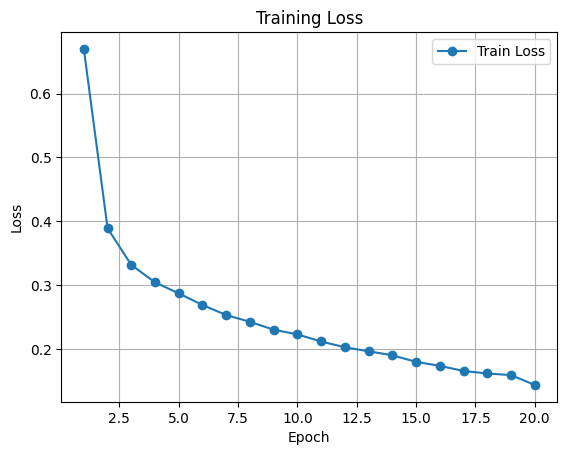

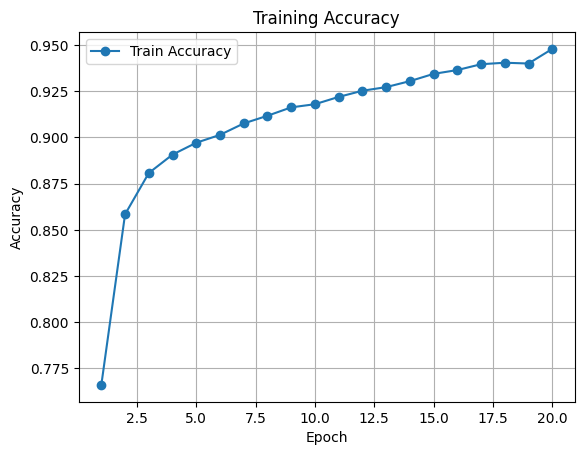

In [16]:
# ===============================
# 12. 학습 과정 시각화
# ===============================

# epoch 번호를 1부터 M_EPOCH까지 생성합니다.
epochs = range(1, M_EPOCH + 1)

# 학습 손실 그래프를 그립니다.
plt.plot(epochs, train_losses, marker="o", label="Train Loss")

# 그래프 제목을 설정합니다.
plt.title("Training Loss")

# x축 이름을 설정합니다.
plt.xlabel("Epoch")

# y축 이름을 설정합니다.
plt.ylabel("Loss")

# 범례를 표시합니다.
plt.legend()

# 격자선을 표시하여 값 변화를 보기 쉽게 합니다.
plt.grid(True)

# 그래프를 출력합니다.
plt.show()

# 학습 정확도 그래프를 그립니다.
plt.plot(epochs, train_accuracies, marker="o", label="Train Accuracy")

# 그래프 제목을 설정합니다.
plt.title("Training Accuracy")

# x축 이름을 설정합니다.
plt.xlabel("Epoch")

# y축 이름을 설정합니다.
plt.ylabel("Accuracy")

# 범례를 표시합니다.
plt.legend()

# 격자선을 표시합니다.
plt.grid(True)

# 그래프를 출력합니다.
plt.show()


In [19]:
# ===============================
# 13. 테스트 데이터 평가
# ===============================

# 테스트 데이터로 모델을 평가합니다.
test_loss, test_acc, truth, pred = evaluate(
    model=model,
    test_loader=test_loader,
    criterion=criterion,
    device=device
)

# 최종 테스트 손실값을 출력합니다.
print("최종 테스트 손실값: {:.4f}".format(test_loss))

# 최종 테스트 정확도를 출력합니다.
print("최종 정확도: {:.2f}%".format(test_acc * 100))

# 혼동 행렬을 계산합니다.
# truth는 실제 정답 클래스 번호이고, pred는 모델이 예측한 클래스 번호입니다.
cm = confusion_matrix(truth, pred)

# 혼동 행렬을 출력합니다.
print("혼동 행렬")
print(cm)

# F1 점수를 계산합니다.
# average='micro'는 전체 샘플을 기준으로 정밀도와 재현율을 계산하는 방식입니다.
f1 = f1_score(truth, pred, average="micro")

# F1 점수를 출력합니다.
print("F1 점수: {:.3f}".format(f1))


최종 테스트 손실값: 0.2558
최종 정확도: 91.08%
혼동 행렬
[[891   0  22   7   3   1  74   0   2   0]
 [  3 978   1  11   2   0   4   0   1   0]
 [ 19   1 918   4  32   0  26   0   0   0]
 [ 30   5  18 892  30   0  21   0   4   0]
 [  3   0  93  22 836   0  46   0   0   0]
 [  0   0   0   0   0 989   0   9   1   1]
 [125   1  85  18  58   0 707   0   6   0]
 [  0   0   0   0   0  19   0 963   1  17]
 [  4   0   0   2   2   3   3   2 984   0]
 [  0   0   1   0   0  16   0  33   0 950]]
F1 점수: 0.911


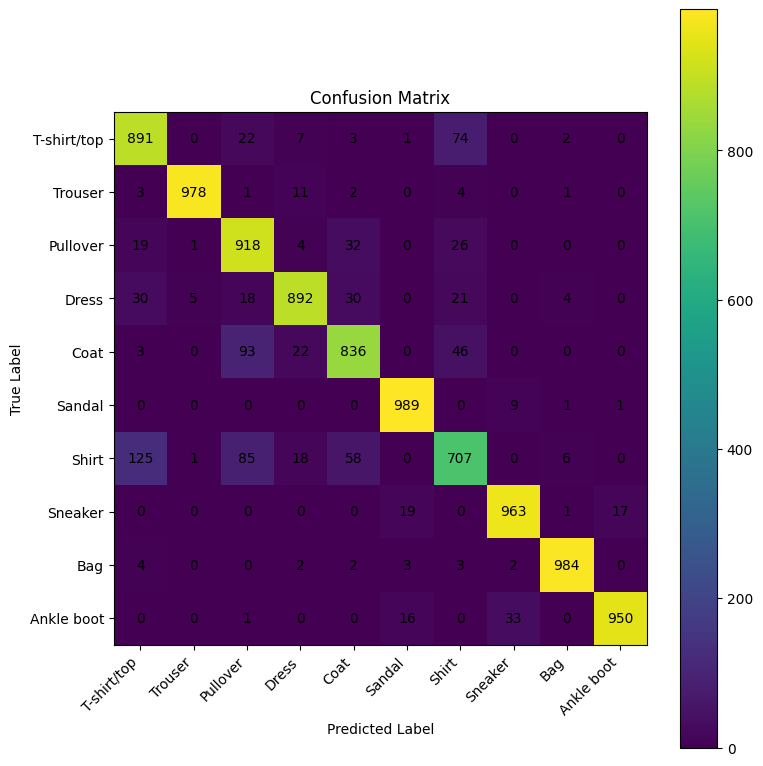

In [20]:
# ===============================
# 14. 혼동 행렬 시각화
# ===============================

# 그래프 크기를 설정합니다.
plt.figure(figsize=(8, 8))

# 혼동 행렬을 이미지 형태로 출력합니다.
plt.imshow(cm)

# 그래프 제목을 설정합니다.
plt.title("Confusion Matrix")

# 컬러바를 표시하여 숫자 크기를 색상으로 해석할 수 있게 합니다.
plt.colorbar()

# x축 눈금 위치를 0~9로 설정합니다.
plt.xticks(np.arange(M_CLASS), class_names, rotation=45, ha="right")

# y축 눈금 위치를 0~9로 설정합니다.
plt.yticks(np.arange(M_CLASS), class_names)

# x축 이름을 설정합니다.
plt.xlabel("Predicted Label")

# y축 이름을 설정합니다.
plt.ylabel("True Label")

# 각 칸에 숫자를 직접 표시합니다.
for i in range(M_CLASS):

    # 각 행 i에 대해 열 j를 반복합니다.
    for j in range(M_CLASS):

        # 혼동 행렬의 i행 j열 값을 해당 위치에 텍스트로 표시합니다.
        plt.text(j, i, cm[i, j], ha="center", va="center")

# 그래프 요소가 잘리지 않도록 레이아웃을 자동 조정합니다.
plt.tight_layout()

# 그래프를 출력합니다.
plt.show()


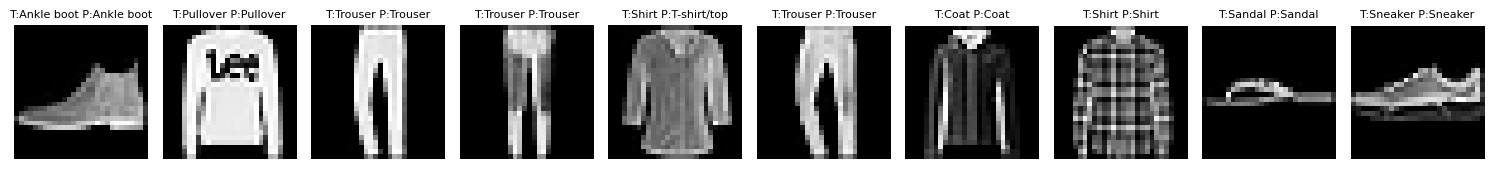

In [22]:
# ===============================
# 15. 예측 결과 샘플 확인
# ===============================

# 테스트 데이터에서 앞쪽 이미지 몇 장을 확인하기 위한 개수입니다.
num_samples = 10

# 테스트 데이터셋에서 앞 num_samples개 이미지를 가져옵니다.
images = []
labels = []

# 지정한 개수만큼 테스트 데이터를 하나씩 꺼냅니다.
for i in range(num_samples):

    # 테스트 데이터셋에서 i번째 이미지와 라벨을 가져옵니다.
    image, label = test_dataset[i]

    # 이미지를 리스트에 추가합니다.
    images.append(image)

    # 라벨을 리스트에 추가합니다.
    labels.append(label)

# 이미지 리스트를 하나의 텐서로 합칩니다.
# 결과 모양은 (num_samples, 1, 28, 28)입니다.
images_tensor = torch.stack(images).to(device)

# 모델을 평가 모드로 전환합니다.
model.eval()

# 예측 과정에서는 기울기 계산이 필요 없으므로 no_grad를 사용합니다.
with torch.no_grad():

    # 모델에 샘플 이미지를 입력하여 예측 점수를 계산합니다.
    outputs = model(images_tensor)

    # 가장 큰 점수를 가진 클래스 번호를 예측값으로 선택합니다.
    _, predicted = torch.max(outputs, dim=1)

# 예측값을 CPU로 이동한 뒤 NumPy 배열로 변환합니다.
predicted = predicted.cpu().numpy()

# 이미지 출력용 캔버스 크기를 설정합니다.
plt.figure(figsize=(15, 4))

# 샘플 개수만큼 반복하면서 이미지를 출력합니다.
for i in range(num_samples):

    # 1행 num_samples열 구조에서 i+1번째 위치를 선택합니다.
    plt.subplot(1, num_samples, i + 1)

    # 이미지 텐서에서 채널 차원을 제거하고 흑백 이미지로 출력합니다.
    plt.imshow(images[i].squeeze(), cmap="gray")

    # 실제 라벨 이름과 예측 라벨 이름을 제목에 표시합니다.
    plt.title(f"T:{class_names[labels[i]]} P:{class_names[predicted[i]]}", fontsize=8)

    # 축 눈금을 숨깁니다.
    plt.axis("off")

# 그래프 요소가 겹치지 않도록 자동 조정합니다.
plt.tight_layout()

# 그래프를 출력합니다.
plt.show()
